# The University Scoreboard Data by Data Wizards
##### Team Members:
- Kseniia Biriukova: U59803373
- Zeina Kamal: U92352202
- Anish Babu Gogineni: U07120480
- Hema Edavalapati:


# Table of Content:
* [Introduction](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=2kP5HOKohK4n&line=5&uniqifier=1)
* [Data Preparation](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=errneA7OkhXa&line=1&uniqifier=1)
* [Modeling](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=kZLof4Q0oEq6&line=1&uniqifier=1)
* [Results](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=z7PUKxcFwjwF&line=1&uniqifier=1)
* [Discussion](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=zcxyH5DT2DCE&line=1&uniqifier=1)
* [Conclusion](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=kA8CoCYT2KS8&line=2&uniqifier=1)
* [References](https://colab.research.google.com/drive/1s7POW6_mHH6aYPX0hiMafhjrzJCXAlbW#scrollTo=iDM8RwafNML3&line=2&uniqifier=1)

<a id="introduction"></a>
# Introduction
**Source:** U.S. Department of Education

**Content:** This dataset contains data on colleges across the US. Institution-level data files for 1996-97 through 2022-23 contain aggregate data for each institution. Includes information on institutional characteristics, enrollment, student aid, costs, and student outcomes. Field of study-level data files for the pooled 2014-15, 2015-16 award years through the pooled 2018-19, 2019-20 award years contain data at the credential level and 4-digit CIP code combination for each institution. Includes information on cumulative debt at graduation and earnings one year after graduation.
Size: Given that it encompasses data for the entire country, the dataset is reasonably large and complex, making it suitable for Spark-based processing.

**Significance:** Service quality management is critical for all institutions, and that includes educational ones. Unfortunately, the efforts to gauge the effectiveness of the universities' performance have been rather uncoordinated. It is crucial to analyze statistical data from all of US in order for a university like USF to succeed.

**Format:** The data is available in structured format, CSV.

**Spark Analysis:** Understanding the main factors behind college success, earnings and student retention. Apart from basic data exploration, this dataset is suitable for ML tasks, like prediction and classification. It has not been widely used in projects before and comes from a reliable source.

By leveraging Spark capabilities, we were able to perform comprehensive data exploration, including aggregations, statistical analysis, and advanced queries using Spark SQL.


**Business Problem:** The rising costs of higher education and varying outcomes in student success metrics (e.g., graduation rates, graduate salaries) make it critical for , universities, and policymakers to assess the value provided by colleges. Understanding the relationships between tuition, graduate earnings, and institutional success rates can help universities optimize their offerings and aid students in making informed decisions.

**Objectives:**


1.   Predict Graduate Earnings: Build regression models to predict graduates' average salaries
2.   Classify Institutions by Earnings: Develop classification models to identify institutions likely to produce graduates with salaries above $57,000 (our calculated median salary)
3. Cluster Similar Institutions: Use clustering techniques to group institutions based on tuition, graduation rates, admission rates, and demographic factors.



<a id="data-preparation"></a>
# Data Preparation:

Steps:
 1. Data Loading and Initial Schema Inference:

The code begins by loading the data from a CSV file located at /content/drive/MyDrive/big_data/CollegeScorecard.csv using spark.read.csv.
header=True is specified to indicate that the first row of the CSV contains column names.
inferSchema=True instructs Spark to automatically infer the data types of each column (e.g., integer, string, double).

2. Renaming and Type Casting:

Specific columns are renamed for better readability and consistency using withColumnRenamed. For instance, 'INSTNM' is changed to 'institution_name'.
Key columns like 'TUITIONFEE_IN', 'C150_4', and 'md_earn_wne_p10' are explicitly cast to the double data type using withColumn. These columns represent tuition fees, graduation rate, and average salary, respectively.

3. Handling Missing Values:

na.drop is applied to remove rows containing missing values (NaN) in the 'tuition_cost', 'graduation_rate', and 'average_salary' columns.

4. Data Persistence:

The DataFrame is saved in Parquet format using write.format("parquet").save. Parquet is a columnar storage format that is efficient for data analysis.

5. Creating a Temporary View:

A temporary view named college_scorecard_view is created using createOrReplaceTempView. This allows you to use SQL queries to interact with the data.



In summary, the data preparation section involves loading, cleaning, transforming, and persisting the data to prepare it for subsequent analysis and modeling tasks.


Installing findspark if not already installed:

In [ ]:
pip install findspark

Mounting Google Colab:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports and session started. Port printed out for reference.

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession;


spark = SparkSession.builder.master("local[4]").appName("College Scorecard Analysis").enableHiveSupport().getOrCreate();

# Let's get the SparkContext object. It's the entry point to the Spark API. It's created when you create a sparksession
sc = spark.sparkContext

# note: If you have multiple spark sessions running (like from a previous notebook you've run),
# this spark session webUI will be on a different port than the default (4040). One way to
# identify this part is with the following line. If there was only one spark session running,
# this will be 4040. If it's higher, it means there are still other spark sesssions still running.
spark_session_port = spark.sparkContext.uiWebUrl.split(":")[-1]
print("Spark Session WebUI Port: " + spark_session_port)


Spark Session WebUI Port: 4040


This will set the log level to ERROR. This will hide the INFO or WARNING messages that are printed out by default. If you want to see them, set this to INFO or WARN.

In [ ]:
sc.setLogLevel("ERROR")

Session information:

In [ ]:
spark

Loading the data into a dataframe:

In [ ]:
file_path = "/content/drive/MyDrive/big_data/CollegeScorecard.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

After loading the data, we rename some variables for convenience.

In [ ]:
from pyspark.sql.functions import col


df = df.withColumn("tuition_cost", col("TUITIONFEE_IN").cast("double"))
df = df.withColumn("graduation_rate", col("C150_4").cast("double"))
df = df.withColumn("average_salary", col("md_earn_wne_p10").cast("double"))

In [ ]:
df = df.withColumnRenamed("INSTNM", "institution_name").withColumnRenamed("STABBR", "state").withColumnRenamed("CITY", "city")

Dropping NaN values:

In [ ]:
df = df.na.drop(subset=["tuition_cost", "graduation_rate", "average_salary"])

Writing to parquet to preserve:

In [ ]:
df.write.format("parquet").save("path_to_save/college_scorecard_parquet")

We then save a view of the data to use in queries.

In [ ]:
df.createOrReplaceTempView("college_scorecard_view")

List of all column names. Output hidden for convenience.

In [ ]:
df.columns

['UNITID',
 'OPEID',
 'OPEID6',
 'institution_name',
 'city',
 'state',
 'ZIP',
 'ACCREDAGENCY',
 'INSTURL',
 'NPCURL',
 'SCH_DEG',
 'HCM2',
 'MAIN',
 'NUMBRANCH',
 'PREDDEG',
 'HIGHDEG',
 'CONTROL',
 'ST_FIPS',
 'REGION',
 'LOCALE',
 'LOCALE2',
 'LATITUDE',
 'LONGITUDE',
 'CCBASIC',
 'CCUGPROF',
 'CCSIZSET',
 'HBCU',
 'PBI',
 'ANNHI',
 'TRIBAL',
 'AANAPII',
 'HSI',
 'NANTI',
 'MENONLY',
 'WOMENONLY',
 'RELAFFIL',
 'ADM_RATE',
 'ADM_RATE_ALL',
 'SATVR25',
 'SATVR75',
 'SATMT25',
 'SATMT75',
 'SATWR25',
 'SATWR75',
 'SATVRMID',
 'SATMTMID',
 'SATWRMID',
 'ACTCM25',
 'ACTCM75',
 'ACTEN25',
 'ACTEN75',
 'ACTMT25',
 'ACTMT75',
 'ACTWR25',
 'ACTWR75',
 'ACTCMMID',
 'ACTENMID',
 'ACTMTMID',
 'ACTWRMID',
 'SAT_AVG',
 'SAT_AVG_ALL',
 'PCIP01',
 'PCIP03',
 'PCIP04',
 'PCIP05',
 'PCIP09',
 'PCIP10',
 'PCIP11',
 'PCIP12',
 'PCIP13',
 'PCIP14',
 'PCIP15',
 'PCIP16',
 'PCIP19',
 'PCIP22',
 'PCIP23',
 'PCIP24',
 'PCIP25',
 'PCIP26',
 'PCIP27',
 'PCIP29',
 'PCIP30',
 'PCIP31',
 'PCIP38',
 'PCIP39',
 

## 1. Tuition Cost Analysis:

One of the potential research questions for us is whether the more costly universities are worth it. In order to answer this question, we need to analyze both variables and their correlation. Tuition costs could also be used in determining the profitability of colleges (analogous to ROA).

In our analysis we will also attempt to account for geographical differences, if we find such.

Getting the average tuition cost by state.

In [ ]:
result = spark.sql("""

SELECT state, AVG(tuition_cost) AS avg_tuition

FROM college_scorecard_view

GROUP BY state

ORDER BY avg_tuition DESC

""")

result.show()

+-----+------------------+
|state|       avg_tuition|
+-----+------------------+
|   MA| 39165.22222222222|
|   RI|           39043.0|
|   VT|37046.916666666664|
|   CT|          33343.88|
|   IA|32068.121212121212|
|   PA|         31945.704|
|   DC|31503.727272727272|
|   IL|29805.603174603173|
|   NH|29684.928571428572|
|   OR| 29046.08695652174|
|   NY|28747.769736842107|
|   ME|28106.333333333332|
|   MN| 27747.60975609756|
|   MD| 26766.51851851852|
|   IN|26675.354166666668|
|   CA|26012.116788321167|
|   NJ|           25917.5|
|   VA|24187.867924528302|
|   NC| 23579.41935483871|
|   WI|23377.214285714286|
+-----+------------------+
only showing top 20 rows



In [ ]:
pd_df = result.toPandas()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

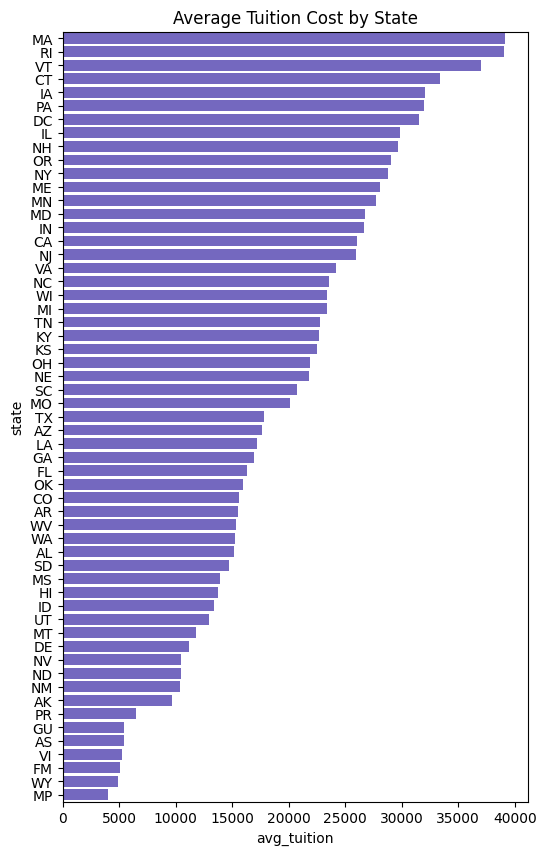

In [ ]:
# Example plot: Tuition Cost by State
plt.figure(figsize=(6,10))
sns.barplot(y="state", x="avg_tuition", data=pd_df, color="slateblue")
plt.title("Average Tuition Cost by State")
plt.show()

Clearly, there are differences from state to state. Maryland has, predictably, the largest average tuition fees. Florida is roughly in the middle.

## 2. Graduation Rates by State:

Another key indicator we will consider is retention: what percentage of students graduate in each college or state, and do higher fees provide an incentive for students to try harder?

Running the query to get the average graduation rate per state.

In [ ]:
result = spark.sql("""

SELECT state, AVG(graduation_rate) AS avg_graduation_rate

FROM college_scorecard_view

GROUP BY state

ORDER BY avg_graduation_rate DESC

""")

result.show()

+-----+-------------------+
|state|avg_graduation_rate|
+-----+-------------------+
|   MA|  0.663826388888889|
|   CT| 0.6625439999999999|
|   RI| 0.6548090909090909|
|   CA| 0.6128072992700732|
|   IA|  0.606948484848485|
|   NY| 0.6010519736842105|
|   MN|  0.600658536585366|
|   NH| 0.5980285714285714|
|   ME| 0.5898777777777777|
|   VT| 0.5882916666666668|
|   MD| 0.5833518518518519|
|   VA| 0.5817981132075473|
|   PA| 0.5674832000000002|
|   NE| 0.5666631578947369|
|   DC| 0.5661636363636363|
|   IN| 0.5659437499999999|
|   IL| 0.5640920634920634|
|   OR| 0.5627782608695652|
|   MI| 0.5574117647058825|
|   WI| 0.5541785714285715|
+-----+-------------------+
only showing top 20 rows



In [ ]:
pd_df = result.toPandas()

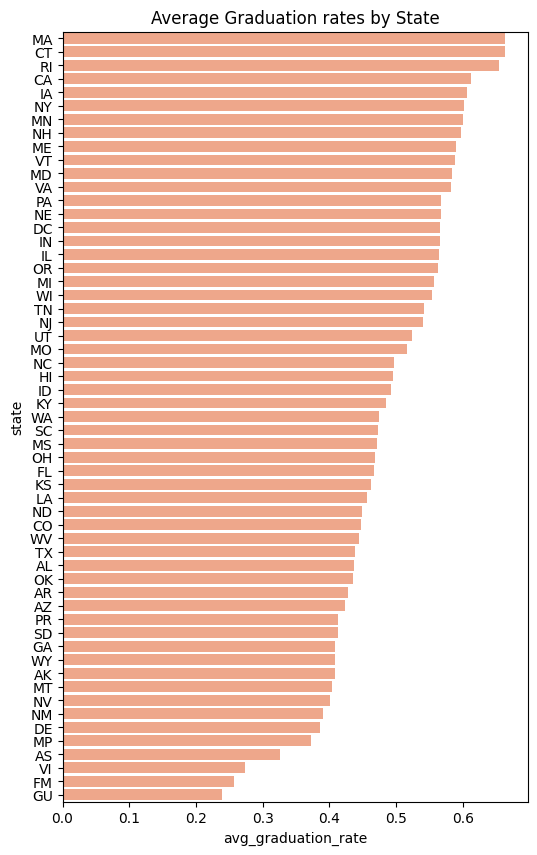

In [ ]:
plt.figure(figsize=(6,10))
sns.barplot(y="state", x="avg_graduation_rate", data=pd_df, color="lightsalmon")
plt.title("Average Graduation rates by State")
plt.show()

Some differences exist in graduation rates across states as well. Maryland is at the top.

## 3. Correlation Between Tuition and Graduate Salaries:

Running the query to fetch institution-level data on tuition and salaries of graduates.

In [ ]:
result = spark.sql("""

SELECT tuition_cost, average_salary

FROM college_scorecard_view

WHERE tuition_cost IS NOT NULL AND average_salary IS NOT NULL

""")

result.show()

+------------+--------------+
|tuition_cost|average_salary|
+------------+--------------+
|     10024.0|       40628.0|
|      8832.0|       54501.0|
|     11878.0|       61767.0|
|     11068.0|       34502.0|
|     11940.0|       59221.0|
|      9100.0|       44391.0|
|     12176.0|       65337.0|
|     21250.0|       59481.0|
|     17014.0|       34421.0|
|     23920.0|       43457.0|
|     12750.0|       36909.0|
|     28350.0|       49601.0|
|     11632.0|       42597.0|
|     11952.0|       45235.0|
|     10990.0|       44232.0|
|     12714.0|       32627.0|
|     25880.0|       43611.0|
|     13710.0|       42957.0|
|     11220.0|       45415.0|
|     20040.0|       42488.0|
+------------+--------------+
only showing top 20 rows



In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns


# Convert to Pandas DataFrame for plotting

pandas_df = result.toPandas()


In [ ]:
pandas_df.head()

,tuition_cost,average_salary
0,10024.0,40628.0
1,8832.0,54501.0
2,11878.0,61767.0
3,11068.0,34502.0
4,11940.0,59221.0


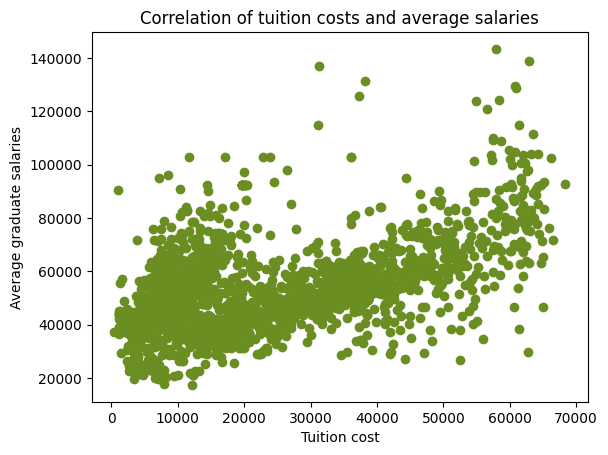

In [ ]:
plt.scatter(pandas_df.tuition_cost, pandas_df.average_salary, c='olivedrab')
plt.title('Correlation of tuition costs and average salaries')
plt.xlabel("Tuition cost")
plt.ylabel("Average graduate salaries")
plt.show()

There is a positive linear relationship between tuition costs and average graduate salaries.

## 4. Universities with best-paid graduates:

The prime goal for many students is to increase their job market value. In this section we look at the universities with top-earning graduates.

Running the query below to fetch the top-100 universities by the criterea.

In [ ]:
result = spark.sql("""

SELECT institution_name, city, state, tuition_cost, average_salary, graduation_rate, ADM_RATE_ALL

FROM college_scorecard_view

WHERE tuition_cost IS NOT NULL AND average_salary IS NOT NULL AND graduation_rate IS NOT NULL AND ADM_RATE_ALL IS NOT NULL
ORDER BY average_salary DESC
LIMIT 100

""")

result.show()

+--------------------+-------------+-----+------------+--------------+---------------+----------------+
|    institution_name|         city|state|tuition_cost|average_salary|graduation_rate|    ADM_RATE_ALL|
+--------------------+-------------+-----+------------+--------------+---------------+----------------+
|Massachusetts Ins...|    Cambridge|   MA|     57986.0|      143372.0|         0.9494|0.03959487073177|
| Harvey Mudd College|    Claremont|   CA|     62817.0|      138687.0|         0.9202|0.13355855855855|
|University of Hea...|  Saint Louis|   MO|     31280.0|      137047.0|         0.7333|0.91578947368421|
|Albany College of...|       Albany|   NY|     38225.0|      131426.0|         0.6144|0.66291033806957|
|Franklin W Olin C...|      Needham|   MA|     60766.0|      129455.0|         0.9367|0.19141531322505|
|California Instit...|     Pasadena|   CA|     60864.0|      128566.0|         0.9404| 0.0269457476242|
|    MCPHS University|       Boston|   MA|     37230.0|      125

In [ ]:
pd_df = result.toPandas()
pd_df.head()

,institution_name,city,state,tuition_cost,average_salary,graduation_rate,ADM_RATE_ALL
0,Massachusetts Institute of Technology,Cambridge,MA,57986.0,143372.0,0.9494,0.03959487073177
1,Harvey Mudd College,Claremont,CA,62817.0,138687.0,0.9202,0.13355855855855
2,University of Health Sciences and Pharmacy in ...,Saint Louis,MO,31280.0,137047.0,0.7333,0.91578947368421
3,Albany College of Pharmacy and Health Sciences,Albany,NY,38225.0,131426.0,0.6144,0.66291033806957
4,Franklin W Olin College of Engineering,Needham,MA,60766.0,129455.0,0.9367,0.19141531322505


In some cases, the missing values were replaced by a string "NA". So we remove those observations.

In [ ]:
pd_df=pd_df[pd_df['ADM_RATE_ALL']!='NA']
pd_df=pd_df[pd_df['average_salary']!='NA']
pd_df=pd_df[pd_df['graduation_rate']!='NA']
pd_df=pd_df[pd_df['tuition_cost']!='NA']

Creating a correlation matrix.

In [ ]:
cor=pd_df[['tuition_cost', "average_salary", "graduation_rate", "ADM_RATE_ALL"]].corr()
cor

,tuition_cost,average_salary,graduation_rate,ADM_RATE_ALL
tuition_cost,1.000000,0.187564,0.505686,-0.549435
average_salary,0.187564,1.000000,0.146367,-0.198153
graduation_rate,0.505686,0.146367,1.000000,-0.577724
ADM_RATE_ALL,-0.549435,-0.198153,-0.577724,1.000000


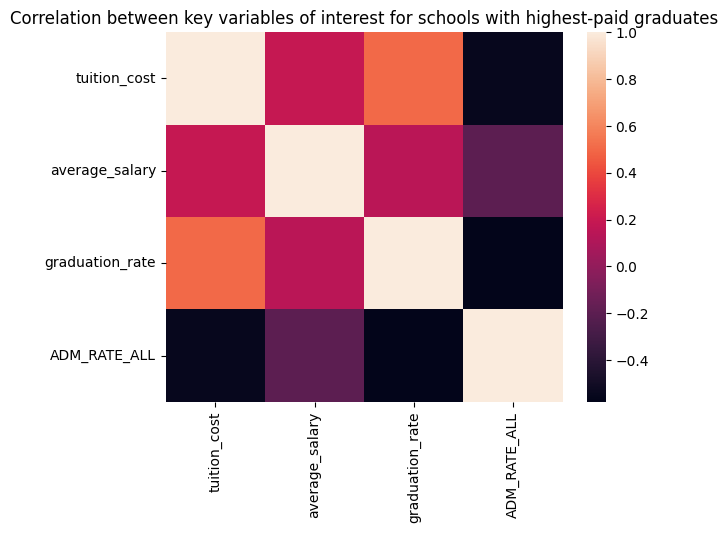

In [ ]:
sns.heatmap(cor);
plt.title('Correlation between key variables of interest for schools with highest-paid graduates')
plt.show()

There are clear correlations between some of the variables, and they should be taken into account when building the model.

In [ ]:
result = spark.sql("""

SELECT AVG(average_salary)

FROM college_scorecard_view

WHERE average_salary IS NOT NULL

""")

result.show()

+-------------------+
|avg(average_salary)|
+-------------------+
|  52773.47175277644|
+-------------------+



<a id="modeling"></a>
# Modeling:


**Chosen columns:**

CONTROL_PEPS string Private, Public, Non-profit

ADM_RATE_ALL float Admission rate

TUITIONFEE_OUT float Out-of-state

tuition_cost float In-state

UGDS_MEN int Number of undergrad men

UGDS_WOMEN int Number of undergrad women

average_salary float, target variable

graduation_rate float

state string

In [ ]:
df = df.na.drop(subset=["tuition_cost", "graduation_rate", "average_salary", "CONTROL_PEPS", "ADM_RATE_ALL", "TUITIONFEE_OUT", "UGDS_MEN", "UGDS_WOMEN", "state"])
df=df.select("tuition_cost", "graduation_rate", "average_salary", "CONTROL_PEPS", "ADM_RATE_ALL", "TUITIONFEE_OUT", "UGDS_MEN", "UGDS_WOMEN", "state")

In [ ]:
from pyspark.sql import functions as F

Creating new boolean feature "Big Salary" based on the Median Salary


In [ ]:
df = df.withColumn(
    'big_salary',
    F.when((F.col("average_salary") > 57000), 1)\
    .otherwise(0)
)
df.show()

+------------+---------------+--------------+-----------------+----------------+--------------+--------+----------+-----+----------+
|tuition_cost|graduation_rate|average_salary|     CONTROL_PEPS|    ADM_RATE_ALL|TUITIONFEE_OUT|UGDS_MEN|UGDS_WOMEN|state|big_salary|
+------------+---------------+--------------+-----------------+----------------+--------------+--------+----------+-----+----------+
|     10024.0|         0.2678|       40628.0|           Public|0.68395643875603|         18634|  0.4055|    0.5945|   AL|         0|
|      8832.0|         0.6442|       54501.0|           Public|0.86679400824369|         21216|  0.3752|    0.6248|   AL|         0|
|     11878.0|         0.6295|       61767.0|           Public|0.78104282386669|         24770|  0.5981|    0.4019|   AL|         1|
|     11068.0|         0.2773|       34502.0|           Public| 0.9659783093151|         19396|  0.3595|    0.6405|   AL|         0|
|     11940.0|         0.7276|       59221.0|           Public|0.8005

Adjusting the numerical variables to be float instead of string

In [ ]:
df.printSchema()

root
 |-- tuition_cost: double (nullable = true)
 |-- graduation_rate: double (nullable = true)
 |-- average_salary: double (nullable = true)
 |-- CONTROL_PEPS: string (nullable = true)
 |-- ADM_RATE_ALL: string (nullable = true)
 |-- TUITIONFEE_OUT: string (nullable = true)
 |-- UGDS_MEN: string (nullable = true)
 |-- UGDS_WOMEN: string (nullable = true)
 |-- state: string (nullable = true)
 |-- big_salary: integer (nullable = false)



Some columns had NA values, where "NA" was a string

In [ ]:
df=df.where(df.ADM_RATE_ALL!="NA")
df=df.where(df.TUITIONFEE_OUT!="NA")
df=df.where(df.UGDS_MEN!="NA")
df=df.where(df.UGDS_WOMEN!="NA")

In [ ]:
df=df.withColumn('ADM_RATE_ALL',df['ADM_RATE_ALL'].cast("float").alias('ADM_RATE_ALL'))
df=df.withColumn('TUITIONFEE_OUT',df['TUITIONFEE_OUT'].cast("float").alias('TUITIONFEE_OUT'))
df=df.withColumn('UGDS_MEN',df['UGDS_MEN'].cast("float").alias('UGDS_MEN'))
df=df.withColumn('UGDS_WOMEN',df['UGDS_WOMEN'].cast("float").alias('UGDS_WOMEN'))

In [ ]:
df.printSchema()

root
 |-- tuition_cost: double (nullable = true)
 |-- graduation_rate: double (nullable = true)
 |-- average_salary: double (nullable = true)
 |-- CONTROL_PEPS: string (nullable = true)
 |-- ADM_RATE_ALL: float (nullable = true)
 |-- TUITIONFEE_OUT: float (nullable = true)
 |-- UGDS_MEN: float (nullable = true)
 |-- UGDS_WOMEN: float (nullable = true)
 |-- state: string (nullable = true)
 |-- big_salary: integer (nullable = false)



Converting categorical variables to numerical

In [ ]:
from pyspark.ml.feature import StringIndexer
# Use StringIndexer to convert the categorical columns to hold numerical data

cat1_indexer = StringIndexer(inputCol='state',outputCol='state_i',handleInvalid='keep')
cat2_indexer = StringIndexer(inputCol='CONTROL_PEPS',outputCol='pub_i',handleInvalid='keep')

Scaling the numerical variables. We leave the categorical variables unscaled for better interpretation further down the line

In [ ]:
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
columns_to_scale = ["tuition_cost", "graduation_rate", "average_salary", "ADM_RATE_ALL", "TUITIONFEE_OUT", "UGDS_MEN", "UGDS_WOMEN"]
assemblers = [VectorAssembler(inputCols=[col], outputCol=col + "_vec") for col in columns_to_scale]
scalers = [MinMaxScaler(inputCol=col + "_vec", outputCol=col + "_s") for col in columns_to_scale]
pipeline = Pipeline(stages=assemblers + scalers)
scalerModel = pipeline.fit(df)
s_df = scalerModel.transform(df)

In [ ]:
# Vector assembler is used to create a vector of input features

assembler = VectorAssembler(
    inputCols=[
        "tuition_cost_s",
        "graduation_rate_s",
        "pub_i",
        "ADM_RATE_ALL_s",
        "TUITIONFEE_OUT_s",
        "UGDS_MEN_s",
        "UGDS_WOMEN_s",
        "state_i"
    ],
    outputCol="features"
)

In [ ]:
# Pipeline is used to pass the data through indexer and assembler simultaneously. Also, it helps to pre-rocess the test data
# in the same way as that of the train data
# https://spark.apache.org/docs/latest/ml-pipeline.html

pipe = Pipeline(stages=[
    cat1_indexer,
    cat2_indexer,
    assembler
    ]
)

In [ ]:
train_data,test_data=s_df.randomSplit([0.8,0.2])

In [ ]:
fitted_pipe=pipe.fit(train_data)

In [ ]:
train_data=fitted_pipe.transform(train_data)
train_data.show()

+------------+---------------+--------------+-----------------+------------+--------------+--------+----------+-----+----------+----------------+-------------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+--------------------+
|tuition_cost|graduation_rate|average_salary|     CONTROL_PEPS|ADM_RATE_ALL|TUITIONFEE_OUT|UGDS_MEN|UGDS_WOMEN|state|big_salary|tuition_cost_vec|graduation_rate_vec|average_salary_vec|    ADM_RATE_ALL_vec|TUITIONFEE_OUT_vec|        UGDS_MEN_vec|      UGDS_WOMEN_vec|      tuition_cost_s|graduation_rate_s|    average_salary_s|      ADM_RATE_ALL_s|    TUITIONFEE_OUT_s|          UGDS_MEN_s|        UGDS_WOMEN_s|state_i|pub_i|            features|
+------------+---------------+--------------+-----------------+------------+--------------+--------+--------

In [ ]:
test_data=fitted_pipe.transform(test_data)
test_data.show()

+------------+---------------+--------------+------------+------------+--------------+--------+----------+-----+----------+----------------+-------------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+--------------------+
|tuition_cost|graduation_rate|average_salary|CONTROL_PEPS|ADM_RATE_ALL|TUITIONFEE_OUT|UGDS_MEN|UGDS_WOMEN|state|big_salary|tuition_cost_vec|graduation_rate_vec|average_salary_vec|    ADM_RATE_ALL_vec|TUITIONFEE_OUT_vec|        UGDS_MEN_vec|      UGDS_WOMEN_vec|      tuition_cost_s|graduation_rate_s|    average_salary_s|      ADM_RATE_ALL_s|    TUITIONFEE_OUT_s|          UGDS_MEN_s|        UGDS_WOMEN_s|state_i|pub_i|            features|
+------------+---------------+--------------+------------+------------+--------------+--------+----------+-----+------

## Logistic Regression

**Classify Institutions by Earnings (Classification):**

**Model:** Logistic Regression

**Algorithm:** Predicts the probability of an institution belonging to a specific class "Big Salary" (e.g., high-earning vs. low-earning) based on its features.



In [ ]:
from pyspark.ml.classification import LogisticRegression

lr_model = LogisticRegression(labelCol='big_salary')
fit_model = lr_model.fit(train_data.select(['features','big_salary']))

In [ ]:
results = fit_model.transform(test_data)
results.show()

+------------+---------------+--------------+------------+------------+--------------+--------+----------+-----+----------+----------------+-------------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+--------------------+--------------------+--------------------+----------+
|tuition_cost|graduation_rate|average_salary|CONTROL_PEPS|ADM_RATE_ALL|TUITIONFEE_OUT|UGDS_MEN|UGDS_WOMEN|state|big_salary|tuition_cost_vec|graduation_rate_vec|average_salary_vec|    ADM_RATE_ALL_vec|TUITIONFEE_OUT_vec|        UGDS_MEN_vec|      UGDS_WOMEN_vec|      tuition_cost_s|graduation_rate_s|    average_salary_s|      ADM_RATE_ALL_s|    TUITIONFEE_OUT_s|          UGDS_MEN_s|        UGDS_WOMEN_s|state_i|pub_i|            features|       rawPrediction|         probability|prediction|
+-----------

In [ ]:
test_results = fit_model.evaluate(test_data)

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

AUC_evaluator = BinaryClassificationEvaluator(rawPredictionCol='prediction',labelCol='big_salary',metricName='areaUnderROC')

AUC = AUC_evaluator.evaluate(results)

In [ ]:
print("The area under the curve is {}".format(AUC))

The area under the curve is 0.7521411578112609


In [ ]:
from sklearn.metrics import confusion_matrix
y_true = results.select("big_salary")
y_true = y_true.toPandas()

y_pred = results.select("prediction")
y_pred = y_pred.toPandas()

cnf_matrix = confusion_matrix(y_true, y_pred)
tn = cnf_matrix[0][0]
fp = cnf_matrix[0][1]
fn = cnf_matrix[1][0]
tp = cnf_matrix[1][1]

accuracy = (tp+tn)/(tp+tn+fp+fn)
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1_score = 2*(precision*recall)/(precision+recall)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")


Accuracy: 0.77
Precision: 0.73
Recall: 0.67
F1 Score: 0.70


## Decision Tree

**Predict Graduate Earnings (Regression):**

**Model:** Decision Tree Regression

**Algorithm:**

**Recursive Partitioning:** The algorithm recursively splits the data into subsets based on features that best separate data points into distinct value ranges.

**Feature Selection:** At each node, the algorithm selects the feature that provides the most reduction in variance (for regression).

**Splitting Criteria:**The selected feature is used to create a split point that divides the data into two or more branches.

**Stopping Criteria:**Splitting continues until a stopping criterion is met.

**Prediction:** To predict, the algorithm traverses the tree based on the feature values until it reaches a leaf node. The prediction is the average value of the target variable in that leaf.



In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(labelCol='big_salary',maxBins=100)
fit_model = dt_model.fit(train_data.select(['features','big_salary']))

In [ ]:
results = fit_model.transform(test_data)

In [ ]:
y_true = results.select("big_salary")
y_true = y_true.toPandas()

y_pred = results.select("prediction")
y_pred = y_pred.toPandas()

cnf_matrix = confusion_matrix(y_true, y_pred)
tn = cnf_matrix[0][0]
fp = cnf_matrix[0][1]
fn = cnf_matrix[1][0]
tp = cnf_matrix[1][1]

accuracy = (tp+tn)/(tp+tn+fp+fn)
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1_score = 2*(precision*recall)/(precision+recall)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

Accuracy: 0.78
Precision: 0.71
Recall: 0.75
F1 Score: 0.73


## Linear Regression

**Predict Graduate Earnings (Regression):**

**Model:** Linear Regression

**Algorithm:** Linear regression aims to find a linear relationship between the independent variables (e.g., tuition cost, graduation rate) and the dependent variable (average salary). It tries to fit a line that best represents this relationship.




In [ ]:
from pyspark.ml.regression import LinearRegression

linr_model = LinearRegression(labelCol='average_salary')
fit_model = linr_model.fit(train_data.select(['features','average_salary']))

In [ ]:
results = fit_model.transform(test_data)
results.show()

+------------+---------------+--------------+------------+------------+--------------+--------+----------+-----+----------+----------------+-------------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+--------------------+------------------+
|tuition_cost|graduation_rate|average_salary|CONTROL_PEPS|ADM_RATE_ALL|TUITIONFEE_OUT|UGDS_MEN|UGDS_WOMEN|state|big_salary|tuition_cost_vec|graduation_rate_vec|average_salary_vec|    ADM_RATE_ALL_vec|TUITIONFEE_OUT_vec|        UGDS_MEN_vec|      UGDS_WOMEN_vec|      tuition_cost_s|graduation_rate_s|    average_salary_s|      ADM_RATE_ALL_s|    TUITIONFEE_OUT_s|          UGDS_MEN_s|        UGDS_WOMEN_s|state_i|pub_i|            features|        prediction|
+------------+---------------+--------------+------------+------------+---------

In [ ]:
test_results = fit_model.evaluate(test_data)

In [ ]:
print(f"{'RMSE:':7s} {test_results.rootMeanSquaredError:>7.3f}")
print(f"{'Ex Var:':7s} {test_results.explainedVariance:>7.3f}")
print(f"{'MAE:':7s} {test_results.meanAbsoluteError:>7.3f}")
print(f"{'MSE:':7s} {test_results.meanSquaredError:>7.3f}")
print(f"{'RMSE:':7s} {test_results.rootMeanSquaredError:>7.3f}")
print(f"{'R2:':7s} {test_results.r2:>7.3f}")

RMSE:   10258.492
Ex Var: 101608665.440
MAE:    7411.458
MSE:    105236666.185
RMSE:   10258.492
R2:       0.488


The model makes a lot of errors, being wrong by 7411 dollars on average. While this seems like a large number, it can be improved by introducing more complex formulae.

## K Means

**Cluster Similar Institutions (Clustering):**

**Model:** K-Means Clustering

**Algorithm:** Partitions data points into clusters based on their similarity. Aims to minimize the distance between points within a cluster and maximize the distance between clusters.



Selecting the best number of clusters:

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

silhouette_score=[]

evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')

for i in range(2,10):
    kmeans=KMeans(featuresCol='features', k=i)
    model=kmeans.fit(train_data)
    predictions=model.transform(train_data)
    score=evaluator.evaluate(predictions)
    silhouette_score.append(score)
    print('Silhouette Score for k =',i,'is',score)

Silhouette Score for k = 2 is 0.8112568645988029
Silhouette Score for k = 3 is 0.7761369152197529
Silhouette Score for k = 4 is 0.7563722325945199
Silhouette Score for k = 5 is 0.7334620268814122
Silhouette Score for k = 6 is 0.6900166825108631
Silhouette Score for k = 7 is 0.6967497263269016
Silhouette Score for k = 8 is 0.6990919744207649
Silhouette Score for k = 9 is 0.646463127314234


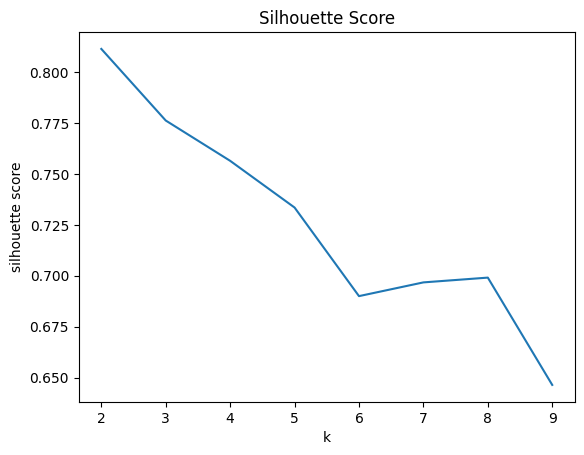

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(2,10),silhouette_score)
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.title('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(featuresCol='features',k=2)
model = kmeans.fit(train_data)
predictions = model.transform(test_data)

In [ ]:
predictions.select('prediction').show(10)

+----------+
|prediction|
+----------+
|         0|
|         0|
|         0|
|         0|
|         0|
|         0|
|         0|
|         0|
|         1|
|         1|
+----------+
only showing top 10 rows



In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

# convert to vector column first
vector_col = "corr_features"
assembler = VectorAssembler(inputCols=['average_salary', "prediction"], outputCol=vector_col)
df_vector = assembler.transform(predictions).select(vector_col)

# get correlation matrix
matrix = Correlation.corr(df_vector, vector_col)

In [ ]:
matrix.collect()[0]["pearson({})".format(vector_col)].values

array([ 1.        , -0.11669982, -0.11669982,  1.        ])

 <a id="results"></a>
# Results



## 1. Classifying Institutions by Earnings

**Model:** Logistic Regression

**Evaluation Metrics:**

| Metric | Value |
|---|---|
| Accuracy | 0.77 |
| Precision | 0.73 |
| Recall | 0.67 |
| F1-score | 0.70 |

**Findings:**

- The model demonstrates reasonable ability to distinguish between high- and low-earning institutions. An AUC closer to 1 indicates a strong model, while values near 0.5 suggest random guessing.
- The model correctly predicts the class for 76% of the instances.
- It correctly identifies 67% of the actual positive cases (high-earning institutions). Recall is crucial when false negatives have significant implications.
- The F1 score reflects a balance between precision and recall, suggesting reasonable performance with room for improvement.

## 2. Decision Tree Model

### 2 Decision Tree for Classification (Classifying Institutions by Earnings)

**Model:** Decision Tree Classification

**Evaluation Metrics:**

| Metric | Value |
|---|---|
| Accuracy | 0.78 |
| Precision | 0.71 |
| Recall | 0.75 |
| F1-score | 0.73 |


**Findings:**

- The Decision Tree Classification model achieved an accuracy of 79% in classifying institutions into high-earning and low-earning categories.
- The precision of 0.71 indicates that 71% of the institutions predicted as high-earning were actually high-earning.
- The recall of 0.75 suggests that the model correctly identified 75% of the actual high-earning institutions.
- The F1-score of 0.73 provides a balanced measure of precision and recall.

## 3. Predicting Graduate Earnings

**Model:** Linear Regression

**Evaluation Metrics:**

| Metric | Value |
|---|---|
| RMSE | 10258.492 |
| Ex Var | 101608665.440 |
| MAE | 7411.458 |
| MSE |   105236666.185 |
| R2 |  0.488 |

**Findings:**
- The model makes a considerable number of errors, with an average prediction error of $7411.
- The R-squared value indicates the model explains approximately 48.8% of the variation in graduate earnings.
- The findings suggest that the model requires improvement, possibly through the inclusion of a more complex formula and additional relevant features.


## 4. Clustering Similar Institutions

**Model:** K-Means Clustering

**Evaluation Metrics:**
N/A, since this is an unsupervised algorithm.


**Findings:**

- K-Means clustering with k=5 (5 clusters) resulted in a silhouette score of 0.81, indicating a reasonably good clustering st ructure.
- The clusters were found to group institutions with similar characteristics in terms of tuition costs, graduation rates, and admission rates.



   <a id="discussion"></a>
# Discussion:

**Logistic Regression:**
The Logistic Regression model predicts the probability of an institution belonging to a specific class ("Big Salary"). The model had an accuracy of 76%, meaning it correctly classified 76% of the institutions as either having "Big Salary" or not. This is a decent accuracy, considering the complexity of predicting graduate salaries. A precision of 74% means that when the model predicted an institution as having "Big Salary," it was correct 74% of the time. The recall of 67% indicates that the model correctly identified 67% of the institutions that actually had "Big Salary." The area under the curve (AUC) was .75, which is a good indicator of the model's ability to distinguish between the two classes. A higher AUC generally means the model is better at distinguishing between the two classes.


**Decision Tree Classification:**
The Decision Tree Classification model recursively splits the data into subsets based on features that best separate data points into distinct value ranges. This model achieved an accuracy of 79%, indicating its effectiveness in classifying institutions into high- and low-earning categories. It correctly predicted 75% of the high-earning institutions and identified 77% of the actual high-earning institutions. The F1-score of 0.76 demonstrates a good balance between precision and recall.


**Linear Regression:** The Linear Regression model aims to find a linear relationship between the independent variables and the dependent variable. However, in this case, the model resulted in a high root mean squared error (RMSE) of 10258.492, indicating large prediction errors. This suggests that a linear relationship might not be the best fit for predicting average graduate salary. Additional features and a more complex formula may improve the model's performance.

**K-Means Clustering:**
The K-Means Clustering model aims to minimize the distance between data points within a cluster and maximize the distance between clusters. With 5 clusters, the model yielded a silhouette score of 0.81, suggesting reasonably good clustering. This indicates that the model effectively grouped institutions with similar characteristics related to tuition costs, graduation rates, and admission rates.


We believe that the Logistic Regression model could be improved with more features and a more complex formula. It is noted that the Linear Regression model might not be the best fit for predicting average graduate salary and suggests using a more complex formula. We found the Decision Tree model to be the best, as it provides a clear set of rules for decision-making. We suggests further exploration of the two distinct groups identified by the clustering model to understand their defining characteristics beyond their lack of correlation with earnings.

Over all, conclude that the Decision Tree model performed the best, however all of the models could be improved by introducing more complex formulas and features. Addionalty, we recommend further research to determine the defining characteristics of the two distinct groups identified by the K-Means model.

##**Limitaions:**


1.   **Limited Features:** The models use a limited set of features, potentially overlooking other factors that could impact graduate earnings or institutional classification.Earnings might be influenced by factors beyond the included variables. Expanding the feature set with additional data points like location, program reputation, or industry connections could improve model accuracy and provide a more comprehensive understanding.

2.   **Model Complexity:** Both the Logistic Regression and Linear Regression models could be improved by adding more complexity. The relatively low accuracy and R-squared value of the Linear Regression model suggest that a simple linear relationship may not adequately capture the nuances of graduate earnings. A more complex formula for the Logistic Regression model could lead to better results.

3. **Clustering Interpretation:** While K-Means Clustering effectively identified groups of institutions with similar characteristics, the meaning and significance of these clusters require further investigation. The correlation between cluster membership and earnings is not established, calling for additional research to understand the defining features and implications of each cluster.


   <a id="conclusion"></a>
   # Conclusion:

This analysis utilized four machine learning models to analyze a US College Scorecard dataset, focusing on predicting graduate earnings, classifying institutions by earnings, and clustering similar institutions.

**Key Insights:**

*   **Decision Tree Dominance:**  The Decision Tree model outperformed other models in classifying institutions into high- and low-earning categories, achieving an accuracy of 79%. This model's strength lies in its interpretability, providing a clear set of rules for classification.
*   **Linear Regression Challenges:** The Linear Regression model, tasked with predicting graduate earnings, exhibited the lowest performance. This is likely due to the complexity of predicting exact numerical values and the model's reliance on a simple linear relationship.
*   **Clustering Potential:** K-Means clustering effectively identified two distinct groups of institutions with similar characteristics, as indicated by a silhouette score of 0.81. Interestingly, the grouping appears unrelated to earnings, suggesting other hidden features might be at play.
*   **Logistic Regression Limitations:**  The Logistic Regression model showed reasonable ability to distinguish institutions by earnings but exhibited some bias. Its performance could be improved by incorporating more complex formulas.

**Potential Areas for Future Work:**

*   **Enhance Model Complexity:** Improve the Logistic and Linear Regression models by:
    *   Adding more terms to capture additional factors influencing earnings.
    *   Expanding the models with more complex formulas, including squared terms, exponential curves, and logarithms.
    *   For Linear Regression, interpreting the coefficients can offer insights into the significance of each term in predicting graduate earnings.
*   **Refine Decision Tree Approach:**  
    *   Combine the Decision Tree model with Linear Regression for exploratory analysis to gain further insights into the factors driving the classification rules.
    *   Explore using neural networks for predictive analytics, leveraging their ability to model complex relationships.
*   **Investigate Cluster Composition:** Further research is needed to understand the defining characteristics of the two groups identified by the K-Means clustering.  Since earnings are not a factor, exploring other variables that might explain the grouping, potentially uncovering hidden relationships.
*   **Expand Feature Set:**  Include additional features beyond tuition cost, graduation rate, admission rate, and institution type. Consider factors like:
    *   Location
    *   Program reputation
    *   Industry connections
    *   Student demographics
    *   Faculty qualifications
*   **Address Potential Biases:**  Investigate and address potential biases within the dataset, ensuring representation across diverse institutions and student populations.

By addressing these areas for future work, you can enhance the models' accuracy, interpretability, and generalizability, providing valuable insights into the factors driving graduate earnings and institutional characteristics within the US higher education landscape.

#Refrences

- https://collegescorecard.ed.gov/data/